# TB Pipeline — Baseline Evaluation

Evaluates the **baseline** pipeline (Grad-CAM lesion proposer, no MoE experts) on all four datasets.  
Outputs are saved to `/kaggle/working/eval_baseline/`.

## Datasets to attach to this notebook
| # | Kaggle dataset slug | What it provides |
|---|---|---|
| 1 | `iahmedhabib/montgomery` | Montgomery CXR images + lung masks |
| 2 | `iahmedhabib/shehzhenn` | Shenzhen CXR images |
| 3 | `usmanshams/tbx-11` | TBX11K images + bounding box annotations |
| 4 | `iahmedhabib/medsam-vit-b` | MedSAM ViT-B checkpoint (~358 MB) |
| 5 | *(your trained checkpoints dataset)* | component1 adapters, component4 decoder, TXV weights |
| 6 | `organizations/nih-chest-xrays` | NIH-CXR14 *(optional — enables pathology AUROC)* |

> **How to create your checkpoints dataset:** zip your local `checkpoints/` folder, upload it to Kaggle as a dataset, then attach it here.

In [1]:
# ── Cell 1: Clone repo and install deps ───────────────────────────────────
import os, subprocess, sys
from pathlib import Path

REPO_DIR = Path('/kaggle/working/repo')
if not REPO_DIR.exists():
    subprocess.run(
        ['git', 'clone', 'https://github.com/mabdullahi7780/dl-project-codebase.git', str(REPO_DIR)],
        check=True
    )
os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'], check=True)
print('Repo ready:', REPO_DIR)

Cloning into '/kaggle/working/repo'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 27.3 MB/s eta 0:00:00
Repo ready: /kaggle/working/repo


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.2.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.


In [ ]:
# ── Cell 2: Paths — edit CHECKPOINTS_ROOT if your dataset slug differs ────
import os
from pathlib import Path

KAGGLE_INPUT = Path('/kaggle/input')

# Dataset roots
MONTGOMERY_ROOT = KAGGLE_INPUT / 'datasets/iahmedhabib/montgomery/montgomery'
SHENZHEN_ROOT   = KAGGLE_INPUT / 'datasets/iahmedhabib/shehzhenn/shenzhen'
TBX11K_ROOT     = KAGGLE_INPUT / 'datasets/usmanshams/tbx-11/TBX11K'
NIH_ROOT        = KAGGLE_INPUT / 'datasets/organizations/nih-chest-xrays/data'  # optional

# ← updated to your dataset slug
CHECKPOINTS_ROOT = KAGGLE_INPUT / 'datasets/mabdullahi454/tb-pipeline-checkpoints'
MEDSAM_CKPT      = KAGGLE_INPUT / 'datasets/iahmedhabib/medsam-vit-b/medsam_vit_b.pth'

# Verify required mounts exist
required = {
    'montgomery': MONTGOMERY_ROOT,
    'shenzhen':   SHENZHEN_ROOT,
    'tbx11k':     TBX11K_ROOT,
    'medsam':     MEDSAM_CKPT,
}
for label, path in required.items():
    status = '✓' if path.exists() else '✗ MISSING'
    print(f'  {label:<12}: {path}  {status}')

nih_available = NIH_ROOT.exists()
print(f'  nih_cxr14   : {"available" if nih_available else "NOT attached (optional)"}')
print(f'  checkpoints : {CHECKPOINTS_ROOT}  {"✓" if CHECKPOINTS_ROOT.exists() else "✗ MISSING"}')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

In [3]:
# ── Cell 3: Write override configs pointing at Kaggle mounts ──────────────
import yaml
from pathlib import Path

OUT_DIR = Path('/kaggle/working/eval_baseline')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Resolve checkpoint paths (auto-detect from checkpoints dataset or repo)
def _find_ckpt(*candidates):
    for c in candidates:
        if Path(c).is_file():
            return str(c)
    return None

c1_adapter = _find_ckpt(
    CHECKPOINTS_ROOT / 'component1/component1_adapters.safetensors',
    CHECKPOINTS_ROOT / 'component1/component1_adapters.pt',
    REPO_DIR / 'checkpoints/component1/component1_adapters.safetensors',
)
c4_decoder = _find_ckpt(
    CHECKPOINTS_ROOT / 'component4/component4_mask_decoder.pt',
    REPO_DIR / 'checkpoints/component4/component4_mask_decoder.pt',
)
c2_routing = _find_ckpt(
    CHECKPOINTS_ROOT / 'component2/component2_routing_head.pt',
    REPO_DIR / 'checkpoints/component2/component2_routing_head.pt',
)

print(f'C1 adapters : {c1_adapter or "NOT FOUND — using frozen backbone"}')
print(f'C4 decoder  : {c4_decoder  or "NOT FOUND — using base decoder"}')
print(f'C2 routing  : {c2_routing  or "NOT FOUND — using default head"}')

# --- paths override ---
paths_cfg = {
    'project_root': str(REPO_DIR),
    'external_data_root': str(KAGGLE_INPUT),
    'datasets': {
        'montgomery': str(MONTGOMERY_ROOT),
        'shenzhen':   str(SHENZHEN_ROOT),
        'tbx11k':     str(TBX11K_ROOT),
        'nih_cxr14':  str(NIH_ROOT) if nih_available else str(OUT_DIR / '_missing_nih'),
    },
    'artifacts': {'notebook_cache': str(OUT_DIR / 'cache'), 'processed': str(OUT_DIR / 'processed'), 'reports': str(OUT_DIR / 'reports')},
}
paths_file = OUT_DIR / 'paths.kaggle.yaml'
paths_file.write_text(yaml.dump(paths_cfg))

# --- baseline config override ---
with (REPO_DIR / 'configs/baseline.yaml').open() as f:
    bl_cfg = yaml.safe_load(f) or {}

bl_cfg.setdefault('runtime', {})['device'] = device
bl_cfg.setdefault('component1', {}).update({'backend': 'auto', 'checkpoint_path': str(MEDSAM_CKPT), 'adapter_path': c1_adapter})
bl_cfg.setdefault('component2', {}).update({'backend': 'auto', 'routing_head_path': c2_routing})
bl_cfg.setdefault('component4', {}).update({'backend': 'auto', 'checkpoint_path': str(MEDSAM_CKPT), 'model_type': 'vit_b', 'decoder_checkpoint_path': c4_decoder})

baseline_file = OUT_DIR / 'baseline.kaggle.yaml'
baseline_file.write_text(yaml.dump(bl_cfg))
print('\nConfigs written.')

C1 adapters : /kaggle/working/repo/checkpoints/component1/component1_adapters.safetensors
C4 decoder  : /kaggle/working/repo/checkpoints/component4/component4_mask_decoder.pt
C2 routing  : /kaggle/working/repo/checkpoints/component2/component2_routing_head.pt

Configs written.


In [4]:
# ── Cell 4: Run baseline evaluation ───────────────────────────────────────
# SMOKE MODE (fast, ~5 min): limit_per_domain=4
# FULL MODE  (all images):   limit_per_domain=200
LIMIT_PER_DOMAIN = 200  # change to 4 for a quick smoke test

from src.evaluation.baseline_eval import run_baseline_evaluation

summary = run_baseline_evaluation(
    baseline_config_path=baseline_file,
    paths_config_path=paths_file,
    output_dir=OUT_DIR,
    limit_per_domain=LIMIT_PER_DOMAIN,
    tbx_list_name='all_trainval.txt',
    repo_root=REPO_DIR,
)
print('\nEvaluation complete.')

Baseline eval device: cuda:Tesla T4
Building manifests …
  montgomery : 138 total samples
  shenzhen   : 662 total samples
  tbx11k     : 8976 total samples
  nih_cxr14  : 112120 total samples
  held-out montgomery : 28 images
  held-out shenzhen   : 132 images
  held-out tbx11k     : 200 images
  held-out nih_cxr14  : 200 images
Loading ground truth (NIH metadata, TBX11K bboxes) …
  NIH multilabels: 112120 images
  TBX11K bbox GT : 799 images
Building pipeline …
Component 1: loaded LoRA+DANN adapters from /kaggle/working/repo/checkpoints/component1/component1_adapters.safetensors
Component 2: loaded routing head from /kaggle/working/repo/checkpoints/component2/component2_routing_head.pt
Component 4: loaded fine-tuned decoder from /kaggle/working/repo/checkpoints/component4/component4_mask_decoder.pt
Running pipeline on held-out images …
  [  20/560] elapsed=  27.2s rate=0.74 img/s eta= 733.4s
  [  40/560] elapsed=  50.4s rate=0.79 img/s eta= 655.1s
  [  60/560] elapsed=  71.9s rate=0.

In [5]:
# ── Cell 5: Display component-level metrics table ─────────────────────────
import pandas as pd

comp_df = pd.read_csv(OUT_DIR / 'baseline_components.csv')
comp_df['value'] = comp_df['value'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')

print('\n=== COMPONENT-LEVEL METRICS ===')
print(comp_df[['metric','dataset','value','n','notes']].to_string(index=False))


=== COMPONENT-LEVEL METRICS ===
                  metric    dataset  value   n                                                                       notes
      c1_domain_accuracy montgomery 0.0000  28                                                                         NaN
      c1_domain_accuracy   shenzhen 0.0000 132                                                                         NaN
      c1_domain_accuracy     tbx11k 0.9950 200                                                                         NaN
      c1_domain_accuracy  nih_cxr14 0.0000 200                                                                         NaN
      c1_domain_accuracy    overall 0.3554 560 target=0.25 (chance) after DANN; >0.25 means encoder is still domain-biased
            c4_lung_dice montgomery 0.8745  28                                                                         NaN
             c4_lung_iou montgomery 0.7846  28                                                            

In [6]:
# ── Cell 6: Display system-level metrics table ────────────────────────────
import pandas as pd

sys_df = pd.read_csv(OUT_DIR / 'baseline_system.csv')
sys_df['value'] = sys_df['value'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')

print('\n=== SYSTEM-LEVEL METRICS (BASELINE) ===')
print(sys_df[['metric','dataset','value','n','notes']].to_string(index=False))


=== SYSTEM-LEVEL METRICS (BASELINE) ===
             metric    dataset   value   n                                                                 notes
           alp_mean montgomery 17.0913  28                                                                   NaN
            alp_std montgomery  3.8815  28                                                                   NaN
            alp_p50 montgomery 16.5169  28                                                                   NaN
            alp_p95 montgomery 24.2404  28                                                                   NaN
           alp_mean   shenzhen 20.0322 132                                                                   NaN
            alp_std   shenzhen  6.5788 132                                                                   NaN
            alp_p50   shenzhen 19.7948 132                                                                   NaN
            alp_p95   shenzhen 30.2052 132             

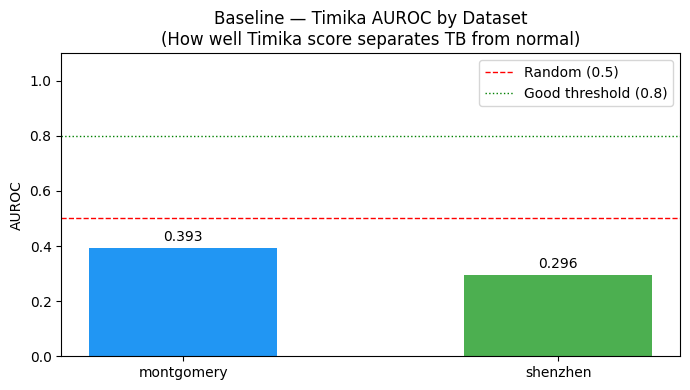

Saved: timika_auroc.png


In [7]:
# ── Cell 7: Timika AUROC bar chart ────────────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt

sys_df = pd.read_csv(OUT_DIR / 'baseline_system.csv')
auroc = sys_df[sys_df['metric'] == 'timika_auroc'].copy()
auroc = auroc[auroc['dataset'] != 'nih_cxr14']  # NIH has no TB labels
auroc['value'] = pd.to_numeric(auroc['value'], errors='coerce')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(auroc['dataset'], auroc['value'], color=['#2196F3','#4CAF50','#FF9800'], width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random (0.5)')
ax.axhline(0.8, color='green', linestyle=':', linewidth=1, label='Good threshold (0.8)')
ax.set_title('Baseline — Timika AUROC by Dataset\n(How well Timika score separates TB from normal)', fontsize=12)
ax.set_ylabel('AUROC')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'timika_auroc.png', dpi=150)
plt.show()
print('Saved: timika_auroc.png')

In [ ]:
# ── Cell 7b: TB Head AUROC (Fix 1) ────────────────────────────────────────
# sigmoid(tb_head(pooled)) = P(TB|image), measured directly.
# AUROC > 0.5 = trained head discriminates TB; ~0.5 = untrained (all outputs 0.5).
import pandas as pd, matplotlib.pyplot as plt

sys_df = pd.read_csv(OUT_DIR / 'baseline_system.csv')
tb_head = sys_df[sys_df['metric'] == 'tb_head_auroc'].copy()
tb_head['value'] = pd.to_numeric(tb_head['value'], errors='coerce')
tb_head = tb_head[tb_head['dataset'] != 'nih_cxr14']

valid = tb_head.dropna(subset=['value'])
if valid.empty:
    print('tb_head_auroc not in CSV — re-run Cell 4 with the updated code to populate this metric.')
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(valid['dataset'], valid['value'], color=['#2196F3', '#4CAF50', '#FF9800'], width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red',   linestyle='--', linewidth=1, label='Random (0.5)')
    ax.axhline(0.8, color='green', linestyle=':',  linewidth=1, label='Good (0.8)')
    ax.set_title('Fix 1 — TB Head AUROC: P(TB|image) from Binary Classifier\n'
                 '(DenseNet121 pooled features → 1-neuron linear TB head)', fontsize=11)
    ax.set_ylabel('AUROC')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'tb_head_auroc.png', dpi=150)
    plt.show()
    print('Saved: tb_head_auroc.png')

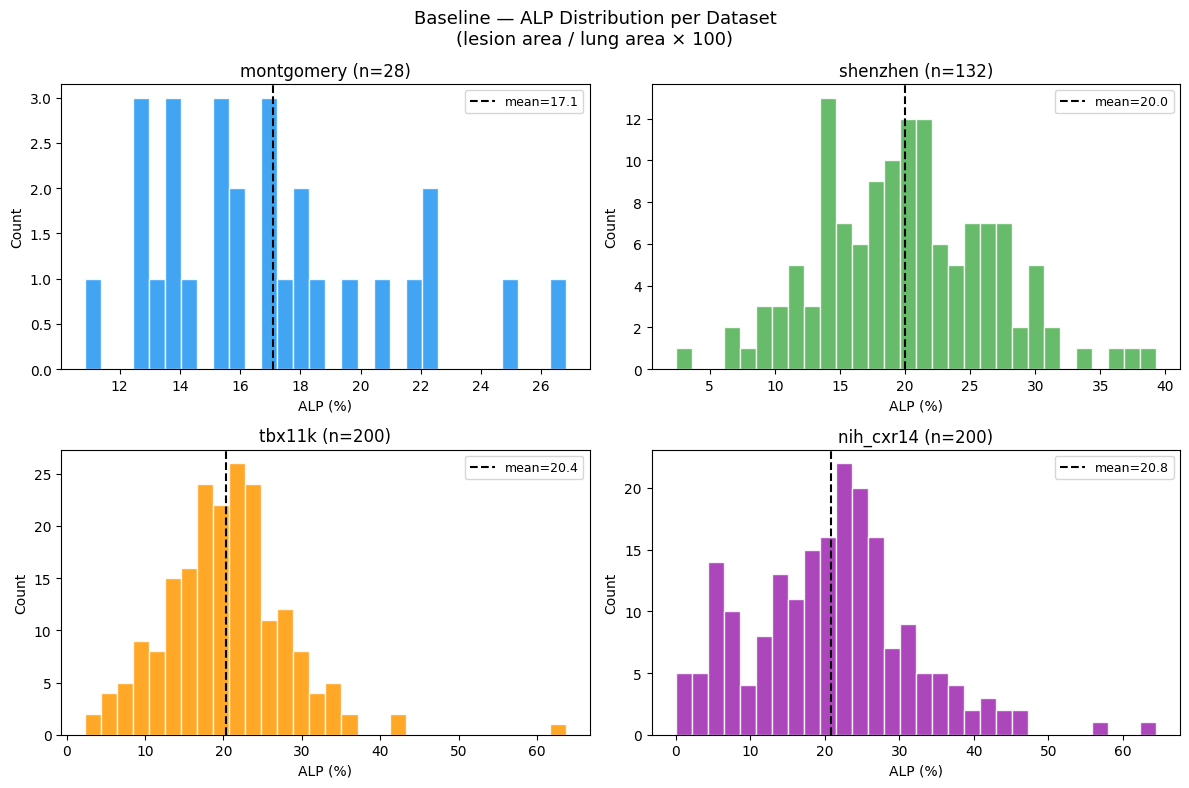

Saved: alp_distribution.png


In [8]:
# ── Cell 8: ALP distribution per dataset ─────────────────────────────────
import pandas as pd, matplotlib.pyplot as plt, numpy as np

pi_df = pd.read_csv(OUT_DIR / 'baseline_per_image.csv')

datasets = ['montgomery', 'shenzhen', 'tbx11k', 'nih_cxr14']
colors   = {'montgomery':'#2196F3','shenzhen':'#4CAF50','tbx11k':'#FF9800','nih_cxr14':'#9C27B0'}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, dom in zip(axes, datasets):
    sub = pi_df[pi_df['dataset_id'] == dom]['alp'].dropna()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', transform=ax.transAxes)
    else:
        ax.hist(sub, bins=30, color=colors[dom], edgecolor='white', alpha=0.85)
        ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean={sub.mean():.1f}')
        ax.set_xlabel('ALP (%)')
        ax.set_ylabel('Count')
        ax.legend(fontsize=9)
    ax.set_title(f'{dom} (n={len(sub)})')

fig.suptitle('Baseline — ALP Distribution per Dataset\n(lesion area / lung area × 100)', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / 'alp_distribution.png', dpi=150)
plt.show()
print('Saved: alp_distribution.png')

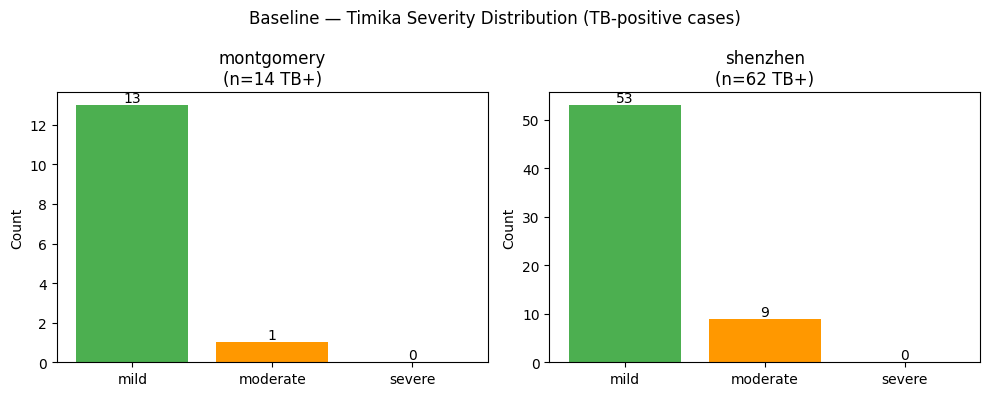

Saved: severity_distribution.png


In [9]:
# ── Cell 9: Severity distribution (TB-positive cases) ────────────────────
import pandas as pd, matplotlib.pyplot as plt

pi_df = pd.read_csv(OUT_DIR / 'baseline_per_image.csv')
tb_pos = pi_df[pi_df['tb_label'] == 1]

sev_order = ['mild', 'moderate', 'severe']
sev_colors = {'mild':'#4CAF50','moderate':'#FF9800','severe':'#f44336'}

datasets = [d for d in ['montgomery','shenzhen','tbx11k'] if d in tb_pos['dataset_id'].values]
fig, axes = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 4))
if len(datasets) == 1:
    axes = [axes]

for ax, dom in zip(axes, datasets):
    sub = tb_pos[tb_pos['dataset_id'] == dom]
    counts = sub['severity'].value_counts()
    vals = [counts.get(s, 0) for s in sev_order]
    bars = ax.bar(sev_order, vals, color=[sev_colors[s] for s in sev_order])
    ax.bar_label(bars)
    ax.set_title(f'{dom}\n(n={len(sub)} TB+)')
    ax.set_ylabel('Count')

fig.suptitle('Baseline — Timika Severity Distribution (TB-positive cases)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'severity_distribution.png', dpi=150)
plt.show()
print('Saved: severity_distribution.png')

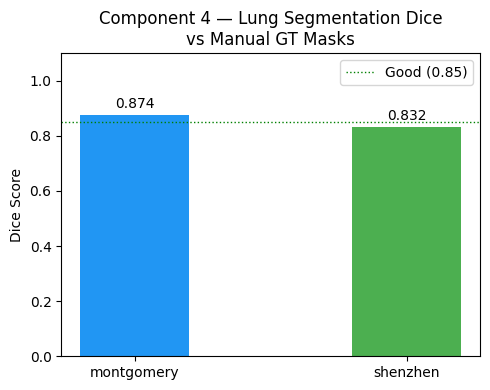

Saved: lung_dice.png


In [10]:
# ── Cell 10: Lung segmentation Dice (Montgomery + Shenzhen) ───────────────
import pandas as pd, matplotlib.pyplot as plt

comp_df = pd.read_csv(OUT_DIR / 'baseline_components.csv')
lung = comp_df[comp_df['metric'] == 'c4_lung_dice'].copy()
lung['value'] = pd.to_numeric(lung['value'], errors='coerce')
lung = lung.dropna(subset=['value'])

if lung.empty:
    print('No lung Dice scores available (GT masks may not be present in this Kaggle version).')
else:
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(lung['dataset'], lung['value'], color=['#2196F3','#4CAF50'], width=0.4)
    ax.bar_label(bars, fmt='%.3f', padding=3)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.85, color='green', linestyle=':', linewidth=1, label='Good (0.85)')
    ax.set_title('Component 4 — Lung Segmentation Dice\nvs Manual GT Masks')
    ax.set_ylabel('Dice Score')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lung_dice.png', dpi=150)
    plt.show()
    print('Saved: lung_dice.png')


=== TB CLASSIFICATION (threshold: Timika > 0) ===
   dataset  accuracy  sensitivity  specificity   n
montgomery     0.500        1.000        0.000  28
  shenzhen     0.470        1.000        0.000 132
    tbx11k     0.000          NaN        0.000  82


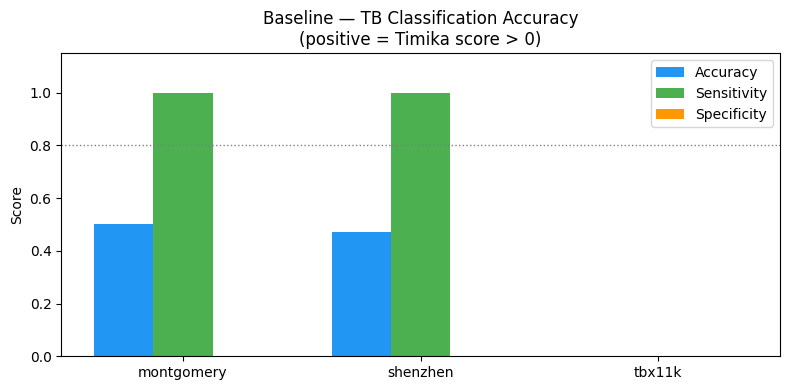

Saved: classification_accuracy.png


In [11]:
# ── Cell 11: TB classification accuracy (sensitivity + specificity) ────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt

pi_df = pd.read_csv(OUT_DIR / 'baseline_per_image.csv')
pi_df = pi_df[pi_df['tb_label'].notna()].copy()
pi_df['tb_label'] = pi_df['tb_label'].astype(int)
pi_df['pred_positive'] = (pi_df['timika_score'] > 0).astype(int)

rows = []
for dom in ['montgomery','shenzhen','tbx11k']:
    sub = pi_df[pi_df['dataset_id'] == dom]
    if sub.empty:
        continue
    tp = ((sub['pred_positive']==1) & (sub['tb_label']==1)).sum()
    tn = ((sub['pred_positive']==0) & (sub['tb_label']==0)).sum()
    fp = ((sub['pred_positive']==1) & (sub['tb_label']==0)).sum()
    fn = ((sub['pred_positive']==0) & (sub['tb_label']==1)).sum()
    sens = tp/(tp+fn) if (tp+fn)>0 else float('nan')
    spec = tn/(tn+fp) if (tn+fp)>0 else float('nan')
    acc  = (tp+tn)/len(sub)
    rows.append({'dataset':dom,'accuracy':acc,'sensitivity':sens,'specificity':spec,'n':len(sub)})

clf_df = pd.DataFrame(rows)
print('\n=== TB CLASSIFICATION (threshold: Timika > 0) ===')
print(clf_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Plot
x = np.arange(len(clf_df))
w = 0.25
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w, clf_df['accuracy'],    width=w, label='Accuracy',    color='#2196F3')
ax.bar(x,   clf_df['sensitivity'], width=w, label='Sensitivity', color='#4CAF50')
ax.bar(x+w, clf_df['specificity'], width=w, label='Specificity', color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(clf_df['dataset'])
ax.set_ylim(0, 1.15)
ax.axhline(0.8, color='grey', linestyle=':', linewidth=1)
ax.set_title('Baseline — TB Classification Accuracy\n(positive = Timika score > 0)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'classification_accuracy.png', dpi=150)
plt.show()
print('Saved: classification_accuracy.png')

In [12]:
# ── Cell 12: Final summary printout ──────────────────────────────────────
import json
from pathlib import Path

summary = json.loads((OUT_DIR / 'baseline_summary.json').read_text())

print('=' * 60)
print('BASELINE EVALUATION — FINAL SUMMARY')
print('=' * 60)
print(f"  Images evaluated : {summary['counts']['ran_ok']}")
print(f"  Images skipped   : {summary['counts']['skipped']}")
print(f"  Device           : {summary['device']}")
print()
print('Output files saved to /kaggle/working/eval_baseline/')
for name, path in summary['output_files'].items():
    print(f'  {name:<20}: {path}')
print('=' * 60)
print('\nDownload these files from the Kaggle Output tab.')

BASELINE EVALUATION — FINAL SUMMARY
  Images evaluated : 560
  Images skipped   : 0
  Device           : cuda:Tesla T4

Output files saved to /kaggle/working/eval_baseline/
  components_csv      : /kaggle/working/eval_baseline/baseline_components.csv
  system_csv          : /kaggle/working/eval_baseline/baseline_system.csv
  per_image_csv       : /kaggle/working/eval_baseline/baseline_per_image.csv
  test_splits         : /kaggle/working/eval_baseline/test_splits.json

Download these files from the Kaggle Output tab.
